# Selecting STN metrics from randomization

Pool the **raw per-STN topological measures** for both location families —
`hamming` (4 classification datasets) and `quantize` (3 regression datasets) —
into one 7-dataset × {real, random} table, and ask **which measures separate the
generalizing (real) regime from the memorizing (random / shuffled-label) one**.

Two readouts:

* **Correlation matrices** — how the measures co-vary, plus each one's
  (point-biserial) correlation with the *memorizing* target.
* **Rankings against random / memorizing** — measures ranked by how strongly they
  move between real and random, both *pooled* (correlation, ignores the dataset)
  and via the dataset-controlled **paired study** (Δ = real − random).

In [2]:
import os, sys
from pathlib import Path

# Run from the repo root
ROOT = Path.cwd()
ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.stn.nx_metrics import paired_study

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", None, "display.width", 200)
METRICS_DIR = ROOT / "results" / "stn_30" / "metrics"

## Raw measures

In [3]:
KEYS = ["dataset", "label_type"]

def pool(battery: str) -> pd.DataFrame:
    # Stack the hamming and quantize raw measures
    return pd.concat(
        [pd.read_csv(METRICS_DIR / f"{loc}_{battery}.csv")
         for loc in ("hamming", "quantize")],
        ignore_index=True,
    )

nx_all = pool("nx-measures")      # structural, fitness-agnostic
lab_all = pool("label-measures")  # label-aware (fitness / role / edge-type)

# All measures side by side: 7 datasets x {real, random} = 14 rows.
combined = nx_all.merge(lab_all, on=KEYS, how="inner")
combined["memorizing"] = (combined["label_type"] == "random").astype(int)

print(f"{combined.shape[0]} rows  x  {combined.shape[1] - 3} measures "
      f"({combined['dataset'].nunique()} datasets, both regimes)")
combined[KEYS + ["memorizing"]]

14 rows  x  67 measures (7 datasets, both regimes)


,dataset,label_type,memorizing
0,Bioresponse,random,1
1,Bioresponse,real,0
2,CIFAR_10,random,1
3,CIFAR_10,real,0
4,Fashion-MNIST,random,1
5,Fashion-MNIST,real,0
6,mnist_784,random,1
7,mnist_784,real,0
8,cars,random,1
9,cars,real,0


## Correlation matrices

Constant measures are dropped. Red = positive, blue = negative.

In [5]:
num = combined.select_dtypes("number")
num = num.loc[:, num.nunique(dropna=False) > 1]
corr = num.corr()
mem_corr = corr["memorizing"].drop("memorizing").dropna()
print(f"{num.shape[1] - 1} kept")

64 kept


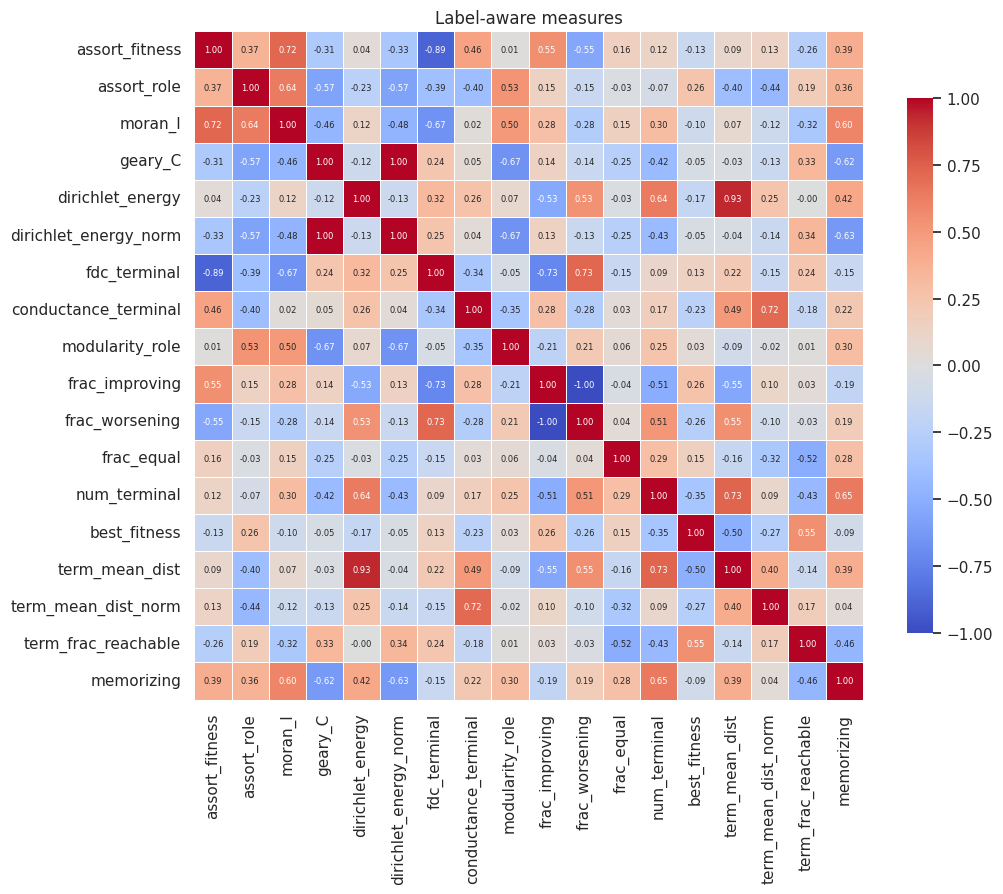

In [6]:
# Label-aware battery: small enough to show in full.
lab_cols = [c for c in lab_all.columns if c not in KEYS and c in num.columns]
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(num[lab_cols + ["memorizing"]].corr(), cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, annot=True, fmt=".2f",
            annot_kws={"size": 6}, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Label-aware measures")
plt.tight_layout()

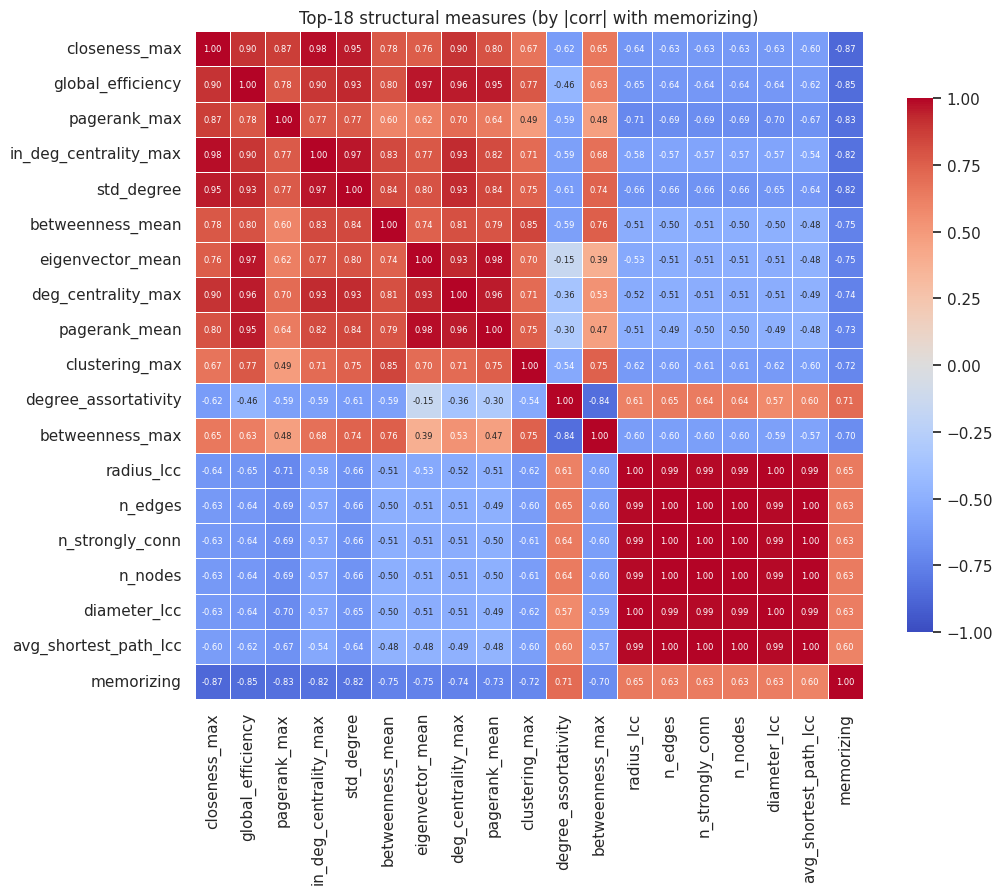

In [7]:
# Structural battery is large; show the measures most correlated with memorizing
nx_cols = [c for c in nx_all.columns if c not in KEYS and c in mem_corr.index]
top_nx = mem_corr.loc[nx_cols].abs().sort_values(ascending=False).head(18).index.tolist()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(num[top_nx + ["memorizing"]].corr(), cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5, annot=True, annot_kws={"size": 6}, fmt=".2f" ,cbar_kws={"shrink": .8}, ax=ax)
ax.set_title("Top-18 structural measures (by |corr| with memorizing)")
plt.tight_layout()

## 3 · Ranking against random / memorizing — pooled

Each measure's point-biserial correlation with `memorizing` (random = 1), ranked
by absolute strength.

- (red) is higher under memorizing,

- (green) is higher under generalizing

,corr_with_memorizing
closeness_max,-0.870991
global_efficiency,-0.849530
pagerank_max,-0.833095
in_deg_centrality_max,-0.821719
std_degree,-0.816122
betweenness_mean,-0.747955
eigenvector_mean,-0.746806
deg_centrality_max,-0.744443
pagerank_mean,-0.730305
clustering_max,-0.721110


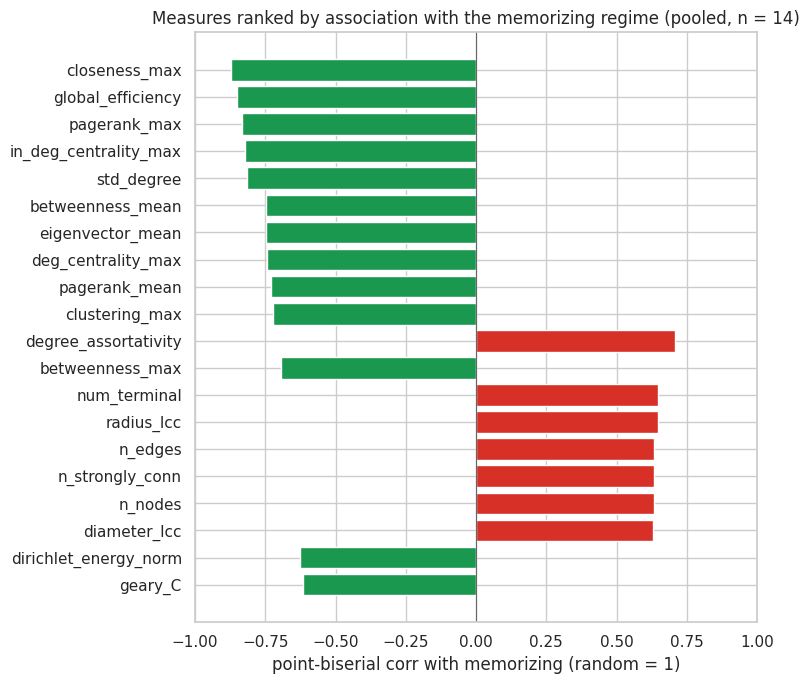

In [8]:
ranked = (mem_corr.rename("corr_with_memorizing").to_frame()
          .assign(abs_corr=lambda d: d["corr_with_memorizing"].abs())
          .sort_values("abs_corr", ascending=False))

top = ranked.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#d73027" if v > 0 else "#1a9850" for v in top["corr_with_memorizing"]]
ax.barh(top.index, top["corr_with_memorizing"], color=colors)
ax.axvline(0, color="0.4", lw=.8)
ax.set_xlim(-1, 1)
ax.set_xlabel("point-biserial corr with memorizing (random = 1)")
ax.set_title("Measures ranked by association with the memorizing regime (pooled, n = 14)")
plt.tight_layout()
ranked.drop(columns="abs_corr").head(20)

In [ ]:
combined.to_csv(METRICS_DIR / "pooled_all-measures.csv", index=False)
ranked.drop(columns="abs_corr").to_csv(METRICS_DIR / "pooled_memorizing-corr.csv")
study.to_csv(METRICS_DIR / "pooled_paired.csv", index=False)

wrote pooled_all-measures.csv, pooled_memorizing-corr.csv, pooled_paired.csv to /home/agudeloacosta/HOMEdev/AE_paper/results/stn_30/metrics
